正在读取全市场数据，请稍候...
正在过滤沪深主板数据...
开始按月执行带滑点和涨跌停限制的调仓模拟...

✅ 交易明细已成功导出至: F:\self_quant\quant\策略交易明细_含涨跌停限制.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 396,506.53 元
📈 策略总收益率: 693.01%


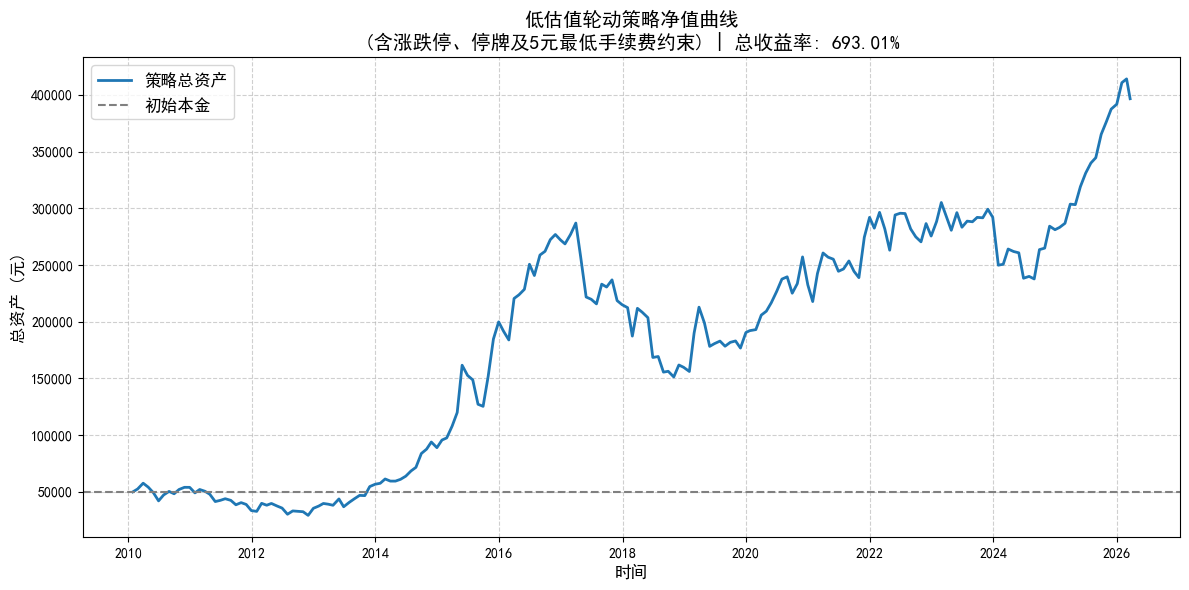

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\quant\策略交易明细_含涨跌停限制.xlsx"

INITIAL_CASH = 50000.0  # 初始本金 5万元
TARGET_STOCK_NUM = 10   # 目标持仓 10 只

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票 (上交所 60 开头，深交所 00 开头)
print("正在过滤沪深主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# 按照日期和代码排序
df.sort_values(by=['date', 'code'], inplace=True)

# 提取每个月的最后一个交易日作为调仓日
df['year_month'] = df['date'].dt.to_period('M')
trade_dates = df.groupby('year_month')['date'].max().sort_values().tolist()

# ==========================================
# 第二步：定义交易费率计算函数
# ==========================================
def calculate_fees(trade_type, price, volume):
    """
    计算交易费用：
    手续费：万分之2.5，最低5元，双向
    过户费：十万分之1，双向
    印花税：万分之5，仅卖出收取
    """
    amount = price * volume
    # 1. 佣金 (最低5元)
    commission = max(5.0, amount * 0.00025)
    # 2. 过户费
    transfer_fee = amount * 0.00001
    # 3. 印花税
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    
    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount

# ==========================================
# 第三步：账户类与回测主引擎
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}  # 格式: {code: {'volume': 股数, 'price': 最新价}}
        self.trade_logs = [] 
        self.history_assets = [] 
        
    def get_total_asset(self, current_date, current_prices_dict):
        # 刷新市值并计算总资产
        stock_value = 0
        for code, pos in self.positions.items():
            # 若停牌无价格，沿用上次价格
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print("开始按月执行带滑点和涨跌停限制的调仓模拟...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    
    # 提取当天的状态字典 (停牌、ST、涨跌幅)
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()
    
    # 计算调仓前总资产并记录
    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})
    
    # ---------------- 选股逻辑 ----------------
    # 选股池要求：正常交易、非ST、PE>0
    valid_pool = daily_data[(daily_data['tradestatus'] == 1) & 
                            (daily_data['isST'] == 0) & 
                            (daily_data['peTTM'] > 0)].copy()
    
    target_codes = []
    if len(valid_pool) >= 50:
        smallest_50 = valid_pool.sort_values(by='流通市值', ascending=True).head(50).copy()
        smallest_50['pe_rank'] = smallest_50['peTTM'].rank()
        smallest_50['pb_rank'] = smallest_50['pbMRQ'].rank()
        smallest_50['score'] = smallest_50['pe_rank'] + smallest_50['pb_rank']
        target_codes = smallest_50.sort_values(by='score').head(TARGET_STOCK_NUM).index.tolist()

    # ---------------- 卖出逻辑 ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            
            # 卖出约束：必须正常交易，且不能跌停 (跌幅小于等于 -9.3% 视为跌停)
            if is_trading and pct_chg > -9.3:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                
                fee, amount = calculate_fees('sell', sell_price, sell_vol)
                
                account.cash += (amount - fee)
                del account.positions[code]
                
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol, 
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), 
                    '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': '正常卖出'
                })
            elif not is_trading:
                # 停牌无法卖出，静默持有
                pass
            elif pct_chg <= -9.3:
                # 跌停无法卖出，记录日志但保留仓位
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), 
                    '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'跌幅 {pct_chg:.2f}% 封死跌停'
                })

    # ---------------- 买入逻辑 ----------------
    # 重新计算可用资金，为需要买入的股票分配额度
    current_asset = account.get_total_asset(date, current_prices)
    
    # 统计当前目标池中我们还没买够的股票数量
    stocks_to_buy = [code for code in target_codes if code not in account.positions]
    
    if len(stocks_to_buy) > 0:
        # 使用当前可用现金均分给需要买入的股票（而不是用总资产算，防止因跌停卖不出导致现金耗尽）
        target_cash_per_stock = account.cash / len(stocks_to_buy)
        
        for code in stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1
            
            # 买入约束：正常交易、非ST、且不能涨停 (涨幅大于等于 9.3% 视为涨停)
            if is_trading and not is_st and pct_chg < 9.3:
                buy_price = current_prices[code]
                
                # 预留千分之三的现金作为手续费缓冲，并计算整手股数
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100
                
                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}
                        
                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol, 
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), 
                            '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '备注': '正常买入'
                        })
            elif pct_chg >= 9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), 
                    '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'涨幅 {pct_chg:.2f}% 封死涨停'
                })

# ==========================================
# 第四步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

# 绘制收益曲线
plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#1f77b4', linewidth=2, label='策略总资产')
# plt.title(f'小市值+低估值轮动策略净值曲线\n(含涨跌停、停牌及5元最低手续费约束) | 总收益率: {total_return:.2f}%', fontsize=14)
plt.title(f'低估值轮动策略净值曲线\n(含涨跌停、停牌及5元最低手续费约束) | 总收益率: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

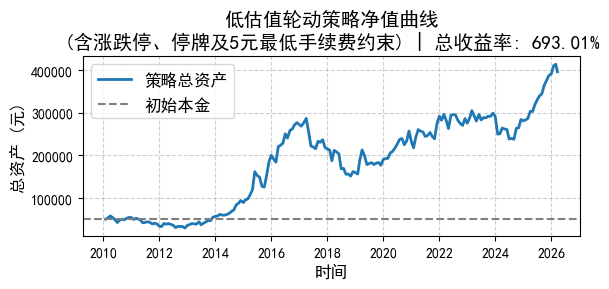

In [4]:
# 绘制收益曲线
plt.figure(figsize=(6, 3))
plt.plot(df_assets.index, df_assets['total_asset'], color='#1f77b4', linewidth=2, label='策略总资产')
# plt.title(f'小市值+低估值轮动策略净值曲线\n(含涨跌停、停牌及5元最低手续费约束) | 总收益率: {total_return:.2f}%', fontsize=14)
plt.title(f'低估值轮动策略净值曲线\n(含涨跌停、停牌及5元最低手续费约束) | 总收益率: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()